![alternative text](../logo.png)

# Climate Indicators – Total Precipitation and Mean Temperature example

This notebook shows how to retrieve **ECDE climate-indicator data** using the `sis-ecde-climate-indicators` dataset, using 
total precipitation and mean temperature as examples.

In this example, you will:

1. Build and send a data request using a **bounding box** or a **polygon**
2. Decode the CoverageJSON data into an **xarray Dataset**
3. Visualise the data using the EarthKit plots package (Optional)

---

### What are ECDE climate indicators?

**ECDE** (**E**uropean **C**limate **D**ata **E**xplorer) climate indicators are derived from CORDEX regional climate simulations. 
The dataset includes variables such as total precipitation, mean temperature, frost days, and heat wave duration across different 
climate scenarios and time periods. 
This type of data supports climate-risk assessment, adaptation planning, and policy-making at the European scale.

More information about **available variables** and **request fields** can be found in: 
- README and constraints/sis-ecde-climate-indicators.json
- https://cds.climate.copernicus.eu/datasets/sis-ecde-climate-indicators?tab=download 


## Imports and shared settings

In [ ]:
# Uncomment and run this cell if you need to install the dependencies
#!pip install -r requirements.txt

In [1]:
#Data requests and decode
import requests
from covjsonkit.api import Covjsonkit

#Data visualisation
import earthkit.plots as ekp

import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="earthkit")

# API endpoint template
base_url = 'https://polytope-dss.ecmwf.int/api/v1/dataset/{dataset}/extract/'

headers = {
    'accept': 'application/json',
    'Content-Type': 'application/json',
}

---

## Example 1 – Bounding-box query

A **bounding box** selects all grid points inside a rectangular region defined by two corner coordinates.

In this example, we pass 2 requests, retrieving **total precipitation** with yearly temporal aggregation for 2 scenarios: RCP4.5 and RCP8.5.

The bounding box covers an area in **Iberian Peninsula** (roughly 36°N–44°N, 10°W–3.5°E).

The API returns data in **CoverageJSON** format. 


### 1.1 Send the request

In [2]:
bbox_request45 = {
    'request': {
        'origin': 'projections',
        'variable': ['total_precipitation'],
        'temporal_aggregation': ['yearly'],
        'experiment': ['rcp4_5'],
        # Optional – uncomment to pin a specific model combination:
        # 'gcm': 'ec_earth',
        # 'rcm': 'racmo22e',
    },
    'feature': {
        'type': 'boundingbox',
        # Coordinates are [lat_min, lon_min] and [lat_max, lon_max]
        'coordinates': [[36.0, -10.0], [44.0, 3.5]],
    },
}
bbox_request85 = {
    'request': {
        'origin': 'projections',
        'variable': ['total_precipitation'],
        'temporal_aggregation': ['yearly'],
        'experiment': ['rcp8_5'],
    },
    'feature': {
        'type': 'boundingbox',
        'coordinates': [[36.0, -10.0], [44.0, 3.5]],
    },
}

url = base_url.format(dataset='sis-ecde-climate-indicators')
response_bbox45 = requests.post(url, headers=headers, json=bbox_request45)
response_bbox85 = requests.post(url, headers=headers, json=bbox_request85)

#Print the response status code
print('Status RCP4.5:', response_bbox45.status_code)
print('Status RCP8.5:', response_bbox85.status_code)


Status RCP4.5: 200
Status RCP8.5: 200


### 1.2 Decode the response

The module `covjsonkit` converts the downloaded CoverageJSON dataset into an [xarray Dataset](https://docs.xarray.dev/en/stable/), which gives us a labelled overview of the dataset and makes future post-processing straightforward.


In [3]:
decoder_bbox45 = Covjsonkit().decode(response_bbox45.json()); decoder_bbox85 = Covjsonkit().decode(response_bbox85.json())
ds_bbox45 = decoder_bbox45.to_xarray(); ds_bbox85 = decoder_bbox85.to_xarray()
ds_bbox45

<xarray.Dataset> Size: 2MB
Dimensions:              (datetimes: 131, number: 1, steps: 1, points: 1815)
Coordinates:
  * datetimes            (datetimes) <U19 10kB '1970-01-01 00:00:00' ... '210...
  * number               (number) int64 8B 0
  * steps                (steps) int64 8B 0
  * points               (points) int64 15kB 0 1 2 3 4 ... 1811 1812 1813 1814
    latitude             (points) float64 15kB 36.0 36.0 36.0 ... 44.0 44.0 44.0
    longitude            (points) float64 15kB -10.0 -9.75 -9.5 ... 3.0 3.25 3.5
    levelist             (points) float64 15kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
Data variables:
    total_precipitation  (datetimes, number, steps, points) float64 2MB 280.6...
Attributes:
    number:   0
    step:     0
    date:     1970-01-01 00:00:00

### 1.3 Visualise the data

In this example, we are going to plot the projected total precipitation in 2100 for 2 different scenarios.


We use **Earthkit Plots** package to visualise the data. 
Please, find more information and documentation of the package here:
https://earthkit-plots.readthedocs.io


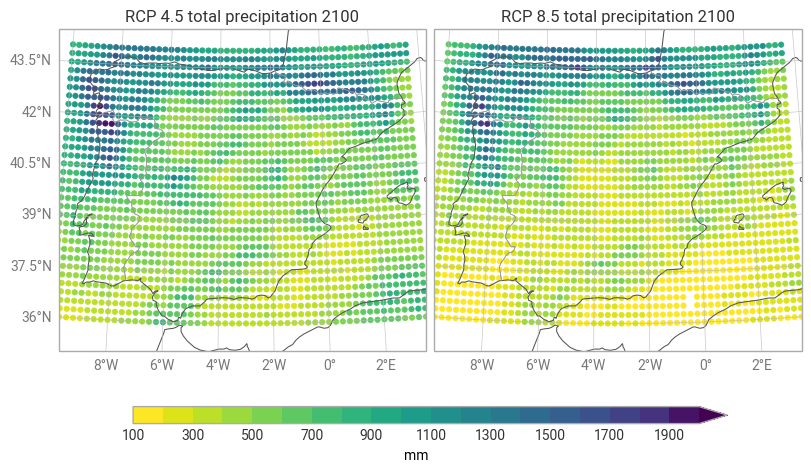

In [4]:
figure = ekp.Figure(rows=1, columns=2, domain="Spain")
ax = figure.add_map()
ax.point_cloud(ds_bbox45['total_precipitation'].isel(datetimes=-1),
    x=ds_bbox45['longitude'],
    y=ds_bbox45['latitude'],
    units='mm',
    s=15,
    style=ekp.Style(levels=range(100,2001,100), colors='viridis_r', extend="max"))
ax.title('RCP 4.5 {variable_name} 2100')

ax = figure.add_map()
ax.point_cloud(ds_bbox85['total_precipitation'].isel(datetimes=-1),
    x=ds_bbox85['longitude'],
    y=ds_bbox85['latitude'],
    units='mm',
    s=15,
    style=ekp.Style(levels=range(100,2001,100), colors='viridis_r', extend="max"))
ax.title('RCP 8.5 {variable_name} 2100')

figure.coastlines()
figure.borders()
figure.gridlines()
figure.legend(label='mm')
figure.show()

We can see that there is less precipitation over the Iberian Peninsula in 2100 in the case of RCP8.5 compared to RCP4.5.

---

## Example 2 – Polygon query

A **polygon** selects grid points inside an arbitrary shape. This is useful when
your area of interest follows administrative boundaries, a river catchment, or
any non-rectangular outline.

Rules for polygon coordinates:

- Each point is `[lat, lon]`
- The polygon must be **closed**: the first and last point must be identical
- At least 4 points are needed (3 unique corners + the closing repeat)

The polygon below roughly traces **Portugal**. Similarly to the Total Precipitation example, we are going to request the **mean temperature** in two scenarios: RCP4.5 and RCP8.5.

### 2.1 Send the request

In [5]:
polygon_request45 = {
    'request': {
        'origin': 'projections',
        'variable': ['mean_temperature'],
        'temporal_aggregation': ['yearly'],
        'experiment': ['rcp4_5'],
    },
    'feature': {
        'type': 'polygon',
        # Closed polygon of [lat, lon] pairs – first point must equal last point
        'coordinates': [[41.870881288,-8.8791360], [41.694339317422646, -8.824238614026456], [40.171924585721314, -8.902386975546364], [38.75694209400925, -9.493088042617785], [38.42424252381525, -9.171674240710018], [38.49907333213173, -8.676525850529856], [37.057269459205145, -8.971873318897366], [37.162874354643776, -7.406745406502978], [38.19776118392036, -6.931663452624974], [38.4280922170291, -7.321584397020473], [39.011852875635526, -6.9787177479519755], [39.66227871551288, -7.5393956904523804], [39.66568774825791, -7.03915852435145], [40.0019453234905, -6.883203763416162], [40.20373392742229, -7.035724907677206], [40.350463990828985, -6.8135246275213035], [41.030499770212515, -6.905947651233703], [41.593647729084154, -6.22847017956974], [41.67712153119277, -6.544984134823352], [41.949682257268876, -6.567927092516641], [41.96960294343674, -7.1747800681640115], [41.88337981339092, -7.196871678410446], [41.81334515396762,-8.156666519264604], [42.14242723772878, -8.205142297350534], [41.870881288,-8.8791360]],
    },
}
polygon_request85 = {
    'request': {
        'origin': 'projections',
        'variable': ['mean_temperature'],
        'temporal_aggregation': ['yearly'],
        'experiment': ['rcp8_5'],
    },
    'feature': {
        'type': 'polygon',
        'coordinates': [[41.870881288,-8.8791360], [41.694339317422646, -8.824238614026456], [40.171924585721314, -8.902386975546364], [38.75694209400925, -9.493088042617785], [38.42424252381525, -9.171674240710018], [38.49907333213173, -8.676525850529856], [37.057269459205145, -8.971873318897366], [37.162874354643776, -7.406745406502978], [38.19776118392036, -6.931663452624974], [38.4280922170291, -7.321584397020473], [39.011852875635526, -6.9787177479519755], [39.66227871551288, -7.5393956904523804], [39.66568774825791, -7.03915852435145], [40.0019453234905, -6.883203763416162], [40.20373392742229, -7.035724907677206], [40.350463990828985, -6.8135246275213035], [41.030499770212515, -6.905947651233703], [41.593647729084154, -6.22847017956974], [41.67712153119277, -6.544984134823352], [41.949682257268876, -6.567927092516641], [41.96960294343674, -7.1747800681640115], [41.88337981339092, -7.196871678410446], [41.81334515396762,-8.156666519264604], [42.14242723772878, -8.205142297350534], [41.870881288,-8.8791360]],
    },
}
url_poly = base_url.format(dataset='sis-ecde-climate-indicators')
response_poly45 = requests.post(url_poly, headers=headers, json=polygon_request45)
response_poly85 = requests.post(url_poly, headers=headers, json=polygon_request85)

# Print the response status code
print('Status RCP4.5:', response_poly45.status_code)
print('Status RCP8.5:', response_poly85.status_code)

Status RCP4.5: 200
Status RCP8.5: 200


### 2.2 Decode the response
As in the previous example, we use `covjsonkit` module to convert the downloaded CoverageJSON dataset into an xarray.

In [7]:
decoder_poly45 = Covjsonkit().decode(response_poly45.json()); decoder_poly85 = Covjsonkit().decode(response_poly85.json())
ds_poly45 = decoder_poly45.to_xarray(); ds_poly85 = decoder_poly85.to_xarray()
ds_poly45

<xarray.Dataset> Size: 174kB
Dimensions:           (datetimes: 131, number: 1, steps: 1, points: 152)
Coordinates:
  * datetimes         (datetimes) <U19 10kB '1970-01-01 00:00:00' ... '2100-0...
  * number            (number) int64 8B 0
  * steps             (steps) int64 8B 0
  * points            (points) int64 1kB 0 1 2 3 4 5 ... 146 147 148 149 150 151
    latitude          (points) float64 1kB 37.25 37.25 37.25 ... 41.75 42.0 42.0
    longitude         (points) float64 1kB -8.75 -8.5 -8.25 ... -6.75 -8.5 -8.25
    levelist          (points) float64 1kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
Data variables:
    mean_temperature  (datetimes, number, steps, points) float64 159kB 289.6 ...
Attributes:
    number:   0
    step:     0
    date:     1970-01-01 00:00:00

### 2.3 Visualise the data

In this example, we are going to plot the projected mean temperature in 2100 for 2 different scenarios, similarly to what we did in the total precipitation example.


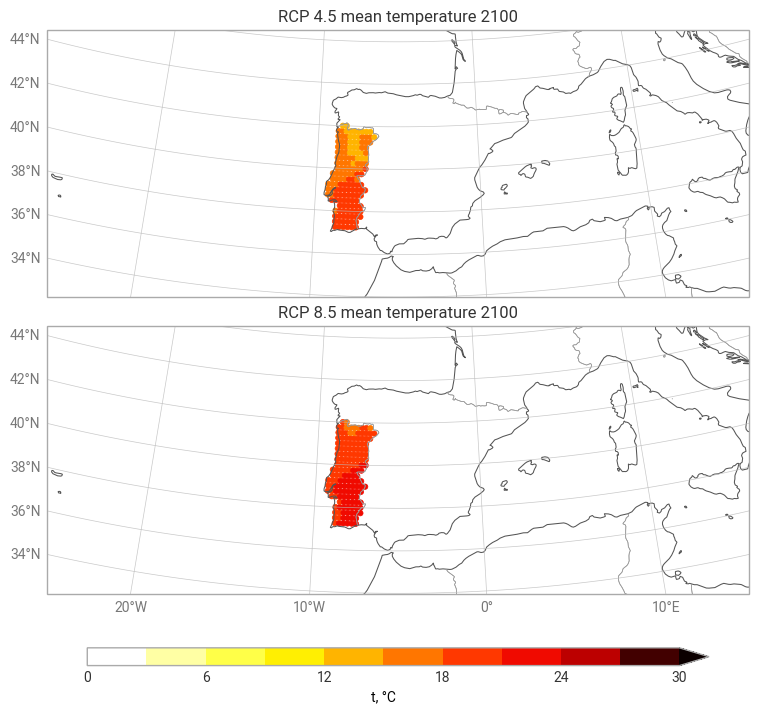

In [8]:
figure = ekp.Figure(rows=2, columns=1, domain="Southwest Europe")
ax = figure.add_map()
ax.point_cloud(ds_poly45['mean_temperature'].isel(datetimes=-1),
    x=ds_poly45['longitude'],
    y=ds_poly45['latitude'],
    units='celsius',
    s=15,
    style=ekp.Style(levels=range(0,31,3), colors='hot_r', extend="max"))
ax.title('RCP 4.5 {variable_name} 2100')

ax = figure.add_map()
ax.point_cloud(ds_poly85['mean_temperature'].isel(datetimes=-1),
    x=ds_poly85['longitude'],
    y=ds_poly85['latitude'],
    units='celsius',
    s=15,
    style=ekp.Style(levels=range(0,31,3), colors='hot_r', extend="max"))
ax.title('RCP 8.5 {variable_name} 2100')

figure.coastlines()
figure.borders()
figure.gridlines()
figure.legend(label='t, °C')
figure.show()

---

## Next steps

Now that you can retrieve the data, here are some things to try next:

- **Swap the variable** – replace total precipitation and mean temperature with any of the available
  indicators (e.g. mean wind speed, fire weather index, tropical nights etc.)
- **Compare model combinations** – run the same request twice with different GCM/RCM pairings and plot them side by side
- **Use a real boundary** – load a country or region shapefile and convert it to a
  polygon for the API

Please see the constraints file, which contains the valid values for the  dataset.
